In [ ]:
#  Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# -------------------------------
# Load Dataset
# -------------------------------

df = pd.read_csv("/content/sample_data/household_power_consumption.txt",
                 sep=';',
                 parse_dates={'DateTime':['Date','Time']},
                 infer_datetime_format=True,
                 low_memory=False,
                 na_values=['?'])

df.head()

,DateTime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df.shape

(2075259, 8)

In [ ]:
# -------------------------------
# Data Cleaning
# -------------------------------

# Convert numeric columns
numeric_cols = ['Global_active_power','Global_reactive_power','Voltage',
                'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']

df[numeric_cols] = df[numeric_cols].astype(float)

# Drop missing values
df.dropna(inplace=True)

# Set datetime index
df.set_index('DateTime', inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
# -------------------------------
# Resample to hourly data
# -------------------------------

df_hourly = df.resample('H').mean()
df_hourly = df_hourly.dropna()

df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [ ]:
# -------------------------------
#  Feature Engineering
# -------------------------------

df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek

# Lag features
df_hourly['lag1'] = df_hourly['Global_active_power'].shift(1)
df_hourly['lag24'] = df_hourly['Global_active_power'].shift(24)

# Rolling mean
df_hourly['rolling_24'] = df_hourly['Global_active_power'].rolling(window=24).mean()

df_hourly.dropna(inplace=True)

df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,lag1,lag24,rolling_24
DateTime,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,6,3.326033,4.222889,2.465140
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,6,3.406767,3.632200,2.467844
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,6,3.697100,3.400233,2.447351
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,6,2.908400,3.268567,2.451224
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,6,3.361500,3.056467,2.450569


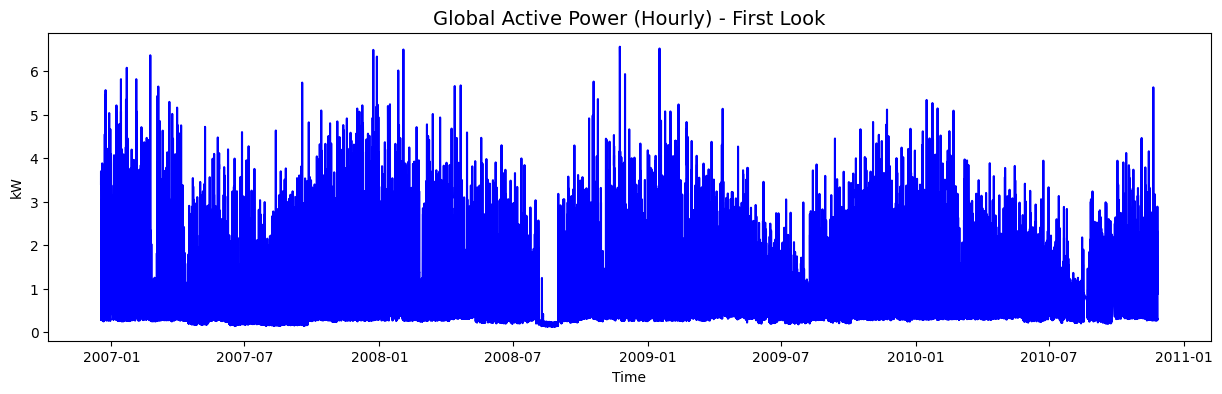

In [ ]:
# -------------------------------------------------------
# Time-Series Plot of Global Active Power
# -------------------------------------------------------

plt.figure(figsize=(15,4))
plt.plot(df_hourly['Global_active_power'], color='blue')
plt.title("Global Active Power (Hourly) - First Look", fontsize=14)
plt.xlabel("Time")
plt.ylabel("kW")
plt.show()

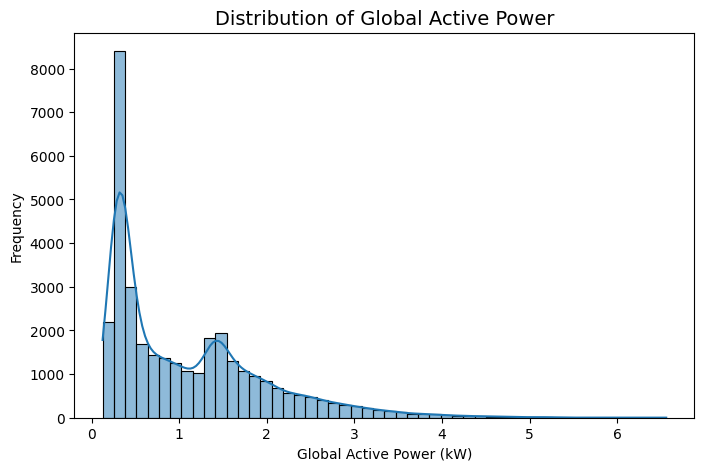

In [ ]:
# -------------------------------------------------------
# Distribution of Global Active Power
# -------------------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df_hourly['Global_active_power'], kde=True, bins=50)
plt.title("Distribution of Global Active Power", fontsize=14)
plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")
plt.show()

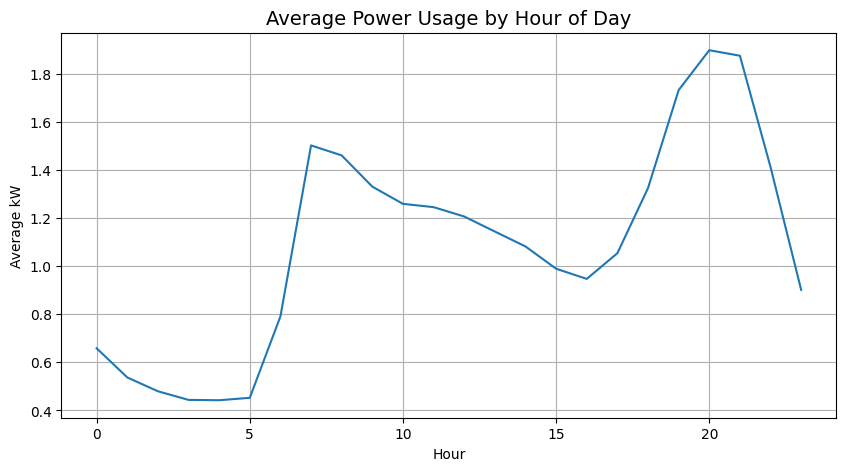

In [ ]:
# -------------------------------------------------------
# Average Usage by Hour
# -------------------------------------------------------

plt.figure(figsize=(10,5))
df_hourly.groupby(df_hourly.index.hour)['Global_active_power'].mean().plot()
plt.title("Average Power Usage by Hour of Day", fontsize=14)
plt.xlabel("Hour")
plt.ylabel("Average kW")
plt.grid(True)
plt.show()

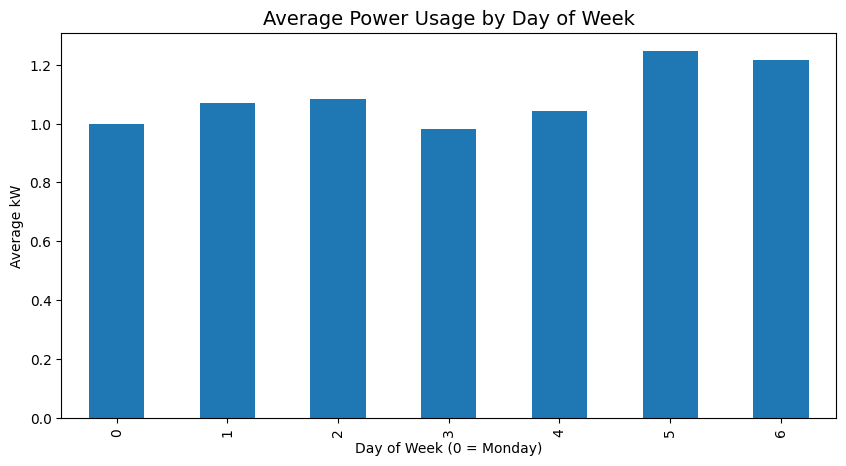

In [ ]:
# -------------------------------------------------------
# Average Usage by Day of Week
# -------------------------------------------------------

plt.figure(figsize=(10,5))
df_hourly.groupby(df_hourly.index.dayofweek)['Global_active_power'].mean().plot(kind='bar')
plt.title("Average Power Usage by Day of Week", fontsize=14)
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Average kW")
plt.show()

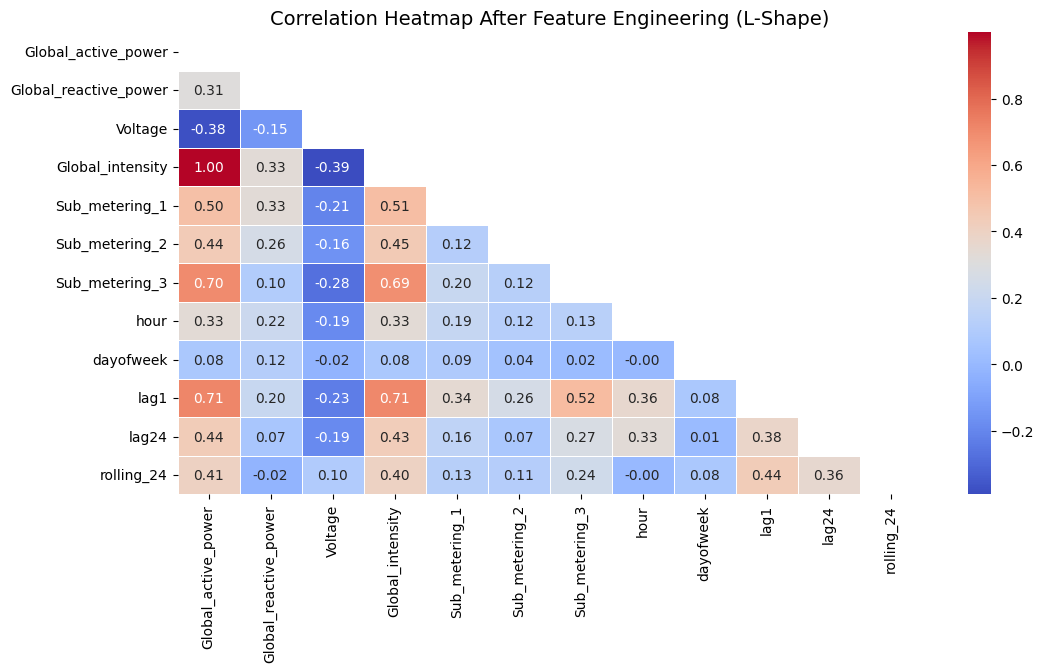

In [ ]:
# -------------------------------------------------------
# L-Shaped Correlation Heatmap
# -------------------------------------------------------

plt.figure(figsize=(12,6))

corr_cols = ['Global_active_power','Global_reactive_power','Voltage',
             'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3',
             'hour','dayofweek','lag1','lag24','rolling_24']

corr = df_hourly[corr_cols].corr()

# Create mask for L-shape (upper triangle mask)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,                    # L-shape mask
    annot=True,                   # numbers inside cells
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap After Feature Engineering (L-Shape)", fontsize=14)
plt.show()

In [ ]:
# -------------------------------------------------------
#  Time-Series Train/Test Split (No Shuffle)
# -------------------------------------------------------

# Define target and features
target = 'Global_active_power'

feature_cols = ['Global_reactive_power','Voltage','Global_intensity',
                'Sub_metering_1','Sub_metering_2','Sub_metering_3',
                'hour','dayofweek','lag1','lag24','rolling_24']

X = df_hourly[feature_cols]
y = df_hourly[target]

# Time-series split: 80% train, 20% test
split_point = int(len(df_hourly) * 0.8)

X_train = X.iloc[:split_point]
X_test  = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test  = y.iloc[split_point:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Train start:", X_train.index.min(), "→ Train end:", X_train.index.max())
print("Test start:", X_test.index.min(),   "→ Test end:", X_test.index.max())

Training samples: 27315
Testing samples: 6829
Train start: 2006-12-17 17:00:00 → Train end: 2010-02-05 09:00:00
Test start: 2010-02-05 10:00:00 → Test end: 2010-11-26 21:00:00


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((27315, 11), (6829, 11), (27315,), (6829,))

In [ ]:
# -------------------------------------------------------
# Train RandomForest Model
# -------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("RandomForest model trained successfully!")

RandomForest model trained successfully!


In [ ]:
# -------------------------------------------------------
# Evaluation Metrics (RMSE, MAE)
# -------------------------------------------------------

rf_preds = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
mae = mean_absolute_error(y_test, rf_preds)

print("RandomForest Performance:")
print("--------------------------")
print("RMSE:", rmse)
print("MAE :", mae)

RandomForest Performance:
--------------------------
RMSE: 0.020961064994550034
MAE : 0.01279522152429174


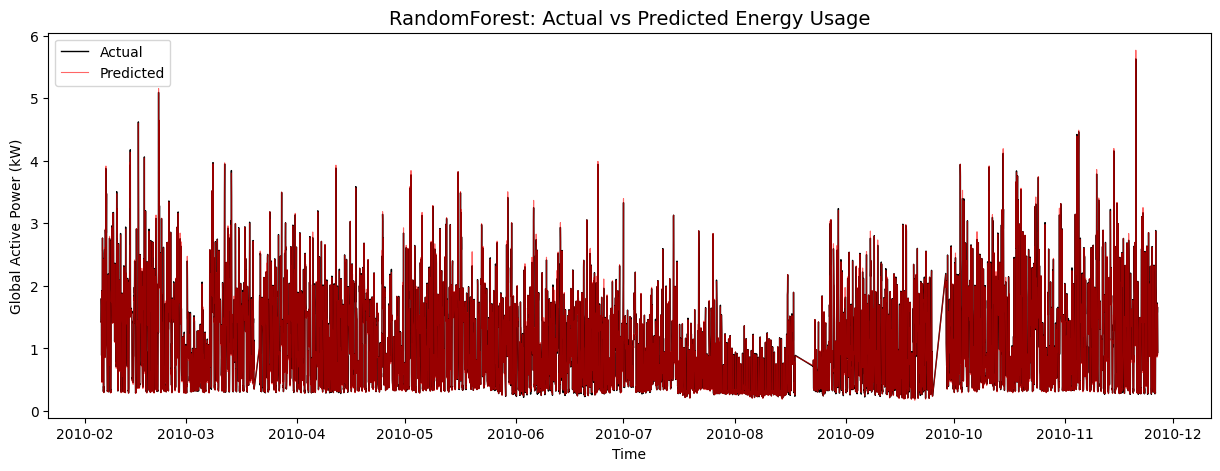

In [ ]:
# -------------------------------------------------------
# Prediction vs Actual Plot
# -------------------------------------------------------

plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label='Actual', color='black', linewidth=1)
plt.plot(y_test.index, rf_preds, label='Predicted', color='red', linewidth=0.8, alpha=0.6)

plt.title("RandomForest: Actual vs Predicted Energy Usage", fontsize=14)
plt.ylabel("Global Active Power (kW)")
plt.xlabel("Time")
plt.legend()
plt.show()

In [ ]:
# -------------------------------------------------------
# Learning Curve for RandomForest
# -------------------------------------------------------

train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)


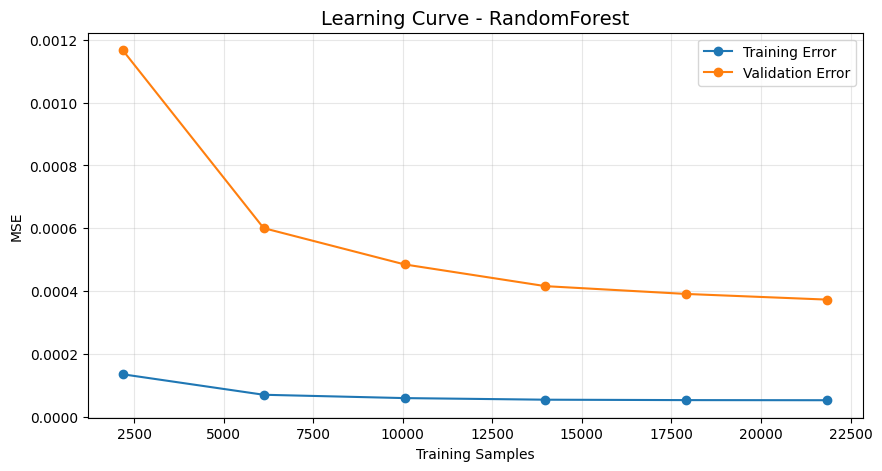

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', label="Validation Error")

plt.grid(True, alpha=0.3)
plt.title("Learning Curve - RandomForest", fontsize=14)
plt.xlabel("Training Samples")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [ ]:
# -------------------------------------------------------
# CELL 16: Train XGBoost Model
# -------------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
# -------------------------------------------------------
# XGBoost Evaluation (RMSE, MAE)
# -------------------------------------------------------

xgb_preds = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))
mae_xgb = mean_absolute_error(y_test, xgb_preds)

print("XGBoost Performance:")
print("----------------------")
print("RMSE:", rmse_xgb)
print("MAE :", mae_xgb)

XGBoost Performance:
----------------------
RMSE: 0.031171828635780306
MAE : 0.018570652467897096


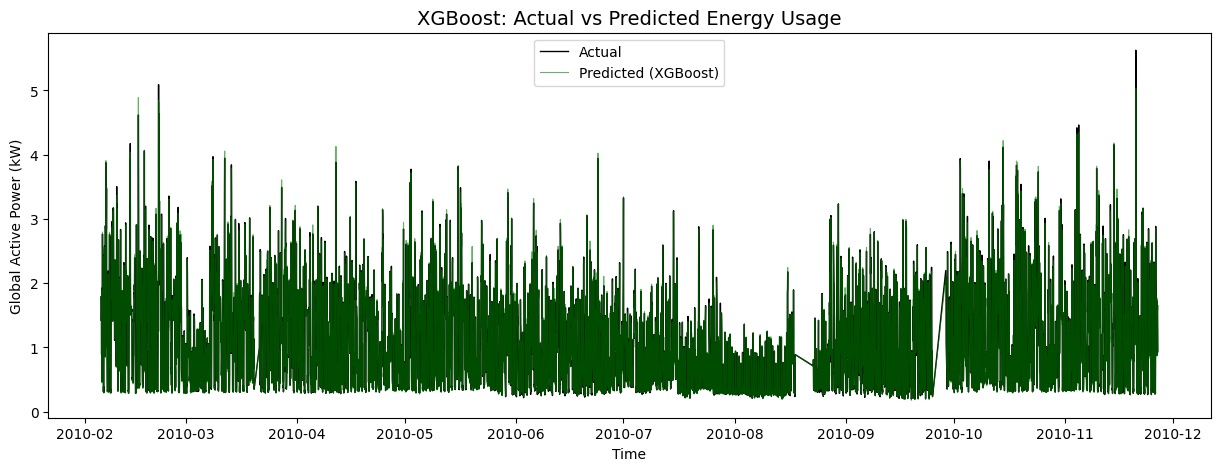

In [ ]:
# -------------------------------------------------------
# XGBoost Predictions vs Actual
# -------------------------------------------------------

plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label='Actual', color='black', linewidth=1)
plt.plot(y_test.index, xgb_preds, label='Predicted (XGBoost)', color='green', linewidth=0.8, alpha=0.6)

plt.title("XGBoost: Actual vs Predicted Energy Usage", fontsize=14)
plt.ylabel("Global Active Power (kW)")
plt.xlabel("Time")
plt.legend()
plt.show()

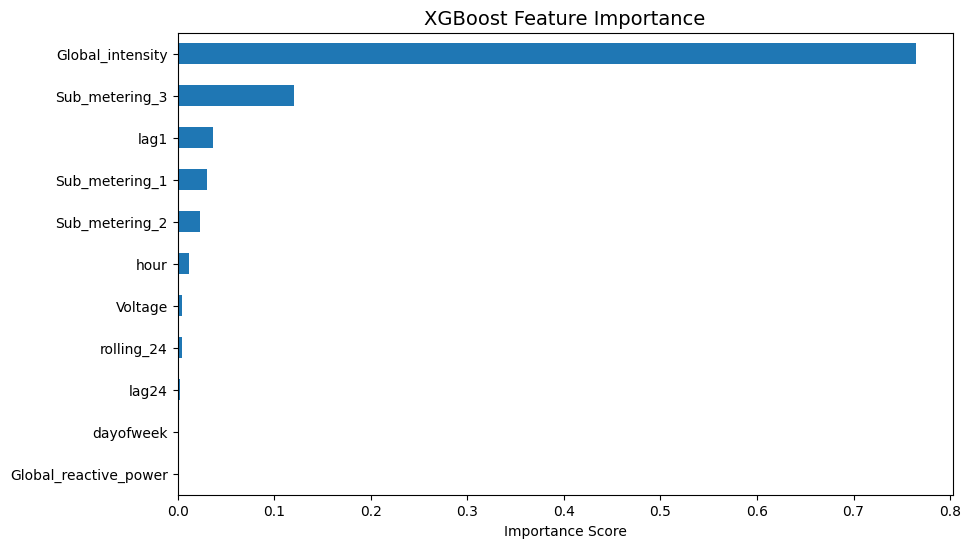

In [ ]:
# -------------------------------------------------------
# XGBoost Feature Importance
# -------------------------------------------------------

importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values()

plt.figure(figsize=(10,6))
importances.plot(kind='barh')
plt.title("XGBoost Feature Importance", fontsize=14)
plt.xlabel("Importance Score")
plt.show()

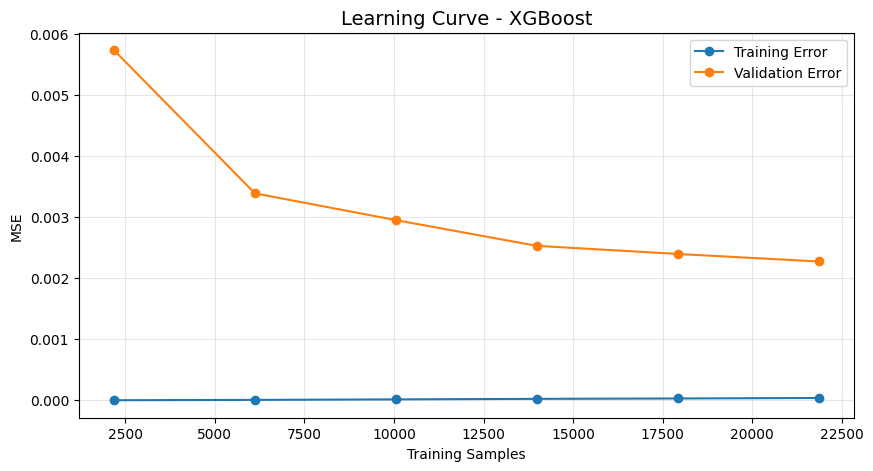

In [ ]:
# -------------------------------------------------------
# Learning Curve - XGBoost
# -------------------------------------------------------

train_sizes, train_scores, test_scores = learning_curve(
    estimator=xgb_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

plt.figure(figsize=(10,5))
plt.plot(train_sizes, train_mean, 'o-', label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', label="Validation Error")
plt.grid(True, alpha=0.3)
plt.title("Learning Curve - XGBoost", fontsize=14)
plt.xlabel("Training Samples")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [ ]:
# -------------------------------------------------------
#  Prepare Data for Prophet
# -------------------------------------------------------

prophet_df = df_hourly.reset_index()[['DateTime','Global_active_power']]

prophet_df.columns = ['ds','y']

prophet_df.head()

,ds,y
0,2006-12-17 17:00:00,3.406767
1,2006-12-17 18:00:00,3.697100
2,2006-12-17 19:00:00,2.908400
3,2006-12-17 20:00:00,3.361500
4,2006-12-17 21:00:00,3.040767


In [ ]:
# -------------------------------------------------------
#  Train Prophet Model
# -------------------------------------------------------

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_df)

print("Prophet model trained successfully!")

Prophet model trained successfully!


In [ ]:
# -------------------------------------------------------
# Create Future Dataframe
# -------------------------------------------------------

future = prophet_model.make_future_dataframe(periods=168, freq='H')

future.tail()

,ds
34307,2010-12-03 17:00:00
34308,2010-12-03 18:00:00
34309,2010-12-03 19:00:00
34310,2010-12-03 20:00:00
34311,2010-12-03 21:00:00


In [ ]:
# -------------------------------------------------------
# Prophet Forecast
# -------------------------------------------------------

forecast = prophet_model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
34307,2010-12-03 17:00:00,1.254560,0.340430,2.213597
34308,2010-12-03 18:00:00,1.607274,0.669102,2.560621
34309,2010-12-03 19:00:00,2.013286,1.097444,2.865990
34310,2010-12-03 20:00:00,2.210367,1.305671,3.113767
34311,2010-12-03 21:00:00,2.063189,1.121211,2.974964


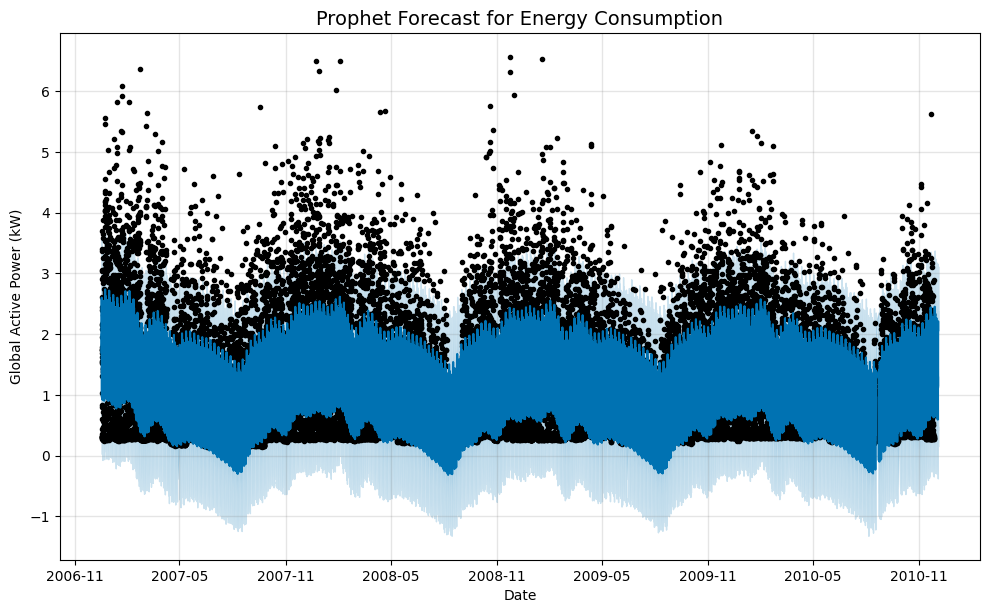

In [ ]:
# -------------------------------------------------------
# Prophet Forecast Plot
# -------------------------------------------------------

fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast for Energy Consumption", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.show()

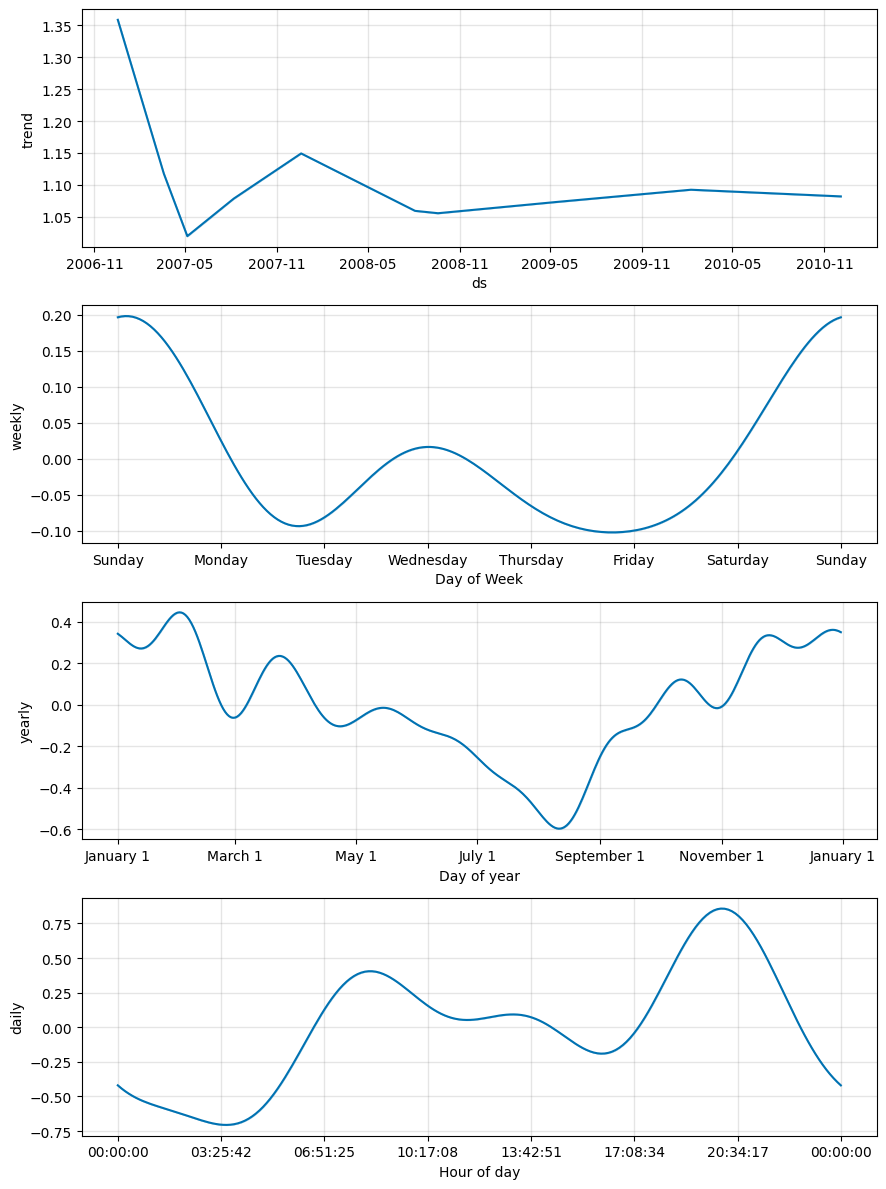

In [ ]:
# -------------------------------------------------------
# Prophet Components
# -------------------------------------------------------

prophet_model.plot_components(forecast)
plt.show()

In [ ]:
# -------------------------------------------------------
# Prophet Evaluation
# -------------------------------------------------------

prophet_test = forecast.set_index('ds').loc[y_test.index]

rmse_prophet = np.sqrt(mean_squared_error(y_test, prophet_test['yhat']))
mae_prophet = mean_absolute_error(y_test, prophet_test['yhat'])

print("Prophet Performance:")
print("--------------------")
print("RMSE:", rmse_prophet)
print("MAE :", mae_prophet)

Prophet Performance:
--------------------
RMSE: 0.628450912856635
MAE : 0.4790611388244291


In [ ]:
# -------------------------------------------------------
# Model Performance Comparison
# -------------------------------------------------------

models = ['RandomForest','XGBoost','Prophet']

rmse_values = [0.02096, 0.03117, 0.62845]
mae_values  = [0.01279, 0.01857, 0.47906]

comparison_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'MAE': mae_values
})

comparison_df

,Model,RMSE,MAE
0,RandomForest,0.02096,0.01279
1,XGBoost,0.03117,0.01857
2,Prophet,0.62845,0.47906


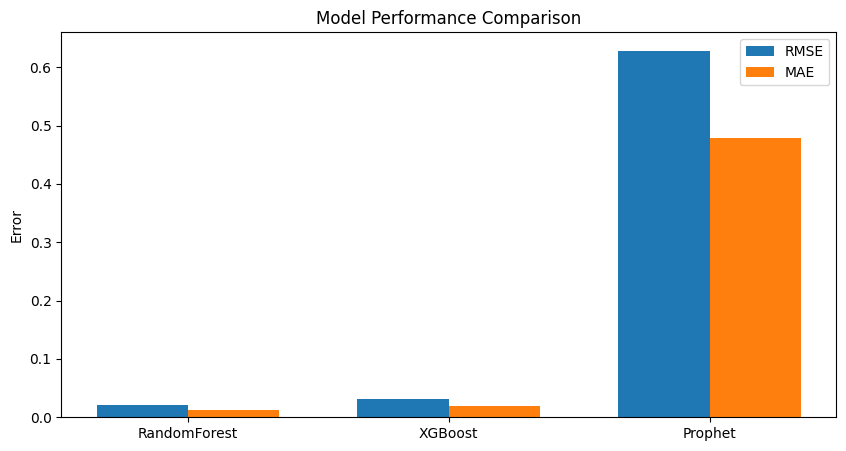

In [ ]:
plt.figure(figsize=(10,5))

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, rmse_values, width, label='RMSE')
plt.bar(x + width/2, mae_values, width, label='MAE')

plt.xticks(x, models)
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.legend()

plt.show()

In [ ]:
# -------------------------------------------------------
# Rolling Statistics for Anomaly Detection
# -------------------------------------------------------

window = 24   # 24 hours window

df_hourly['rolling_mean'] = df_hourly['Global_active_power'].rolling(window).mean()
df_hourly['rolling_std'] = df_hourly['Global_active_power'].rolling(window).std()

df_hourly.dropna(inplace=True)

df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,lag1,lag24,rolling_24,rolling_mean,rolling_std
DateTime,,,,,,,,,,,,,,
2006-12-18 16:00:00,1.949300,0.204433,242.380667,8.096667,0.0,0.000000,17.983333,16,0,1.784300,3.326033,1.642600,1.642600,1.082119
2006-12-18 17:00:00,2.154900,0.097800,238.729167,8.993333,0.0,0.333333,17.450000,17,0,1.949300,3.406767,1.590439,1.590439,1.021879
2006-12-18 18:00:00,2.402533,0.079100,236.668500,10.083333,0.0,0.250000,16.916667,18,0,2.154900,3.697100,1.536499,1.536499,0.936439
2006-12-18 19:00:00,2.614500,0.200767,235.329167,11.190000,0.0,9.100000,0.000000,19,0,2.402533,2.908400,1.524253,1.524253,0.919487
2006-12-18 20:00:00,3.050567,0.120367,234.524333,13.046667,0.0,0.500000,13.250000,20,0,2.614500,3.361500,1.511297,1.511297,0.894320


In [ ]:
# -------------------------------------------------------
# Z-Score Calculation
# -------------------------------------------------------

df_hourly['z_score'] = (
    (df_hourly['Global_active_power'] - df_hourly['rolling_mean']) /
    df_hourly['rolling_std']
)

df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,lag1,lag24,rolling_24,rolling_mean,rolling_std,z_score
DateTime,,,,,,,,,,,,,,,
2006-12-18 16:00:00,1.949300,0.204433,242.380667,8.096667,0.0,0.000000,17.983333,16,0,1.784300,3.326033,1.642600,1.642600,1.082119,0.283425
2006-12-18 17:00:00,2.154900,0.097800,238.729167,8.993333,0.0,0.333333,17.450000,17,0,1.949300,3.406767,1.590439,1.590439,1.021879,0.552376
2006-12-18 18:00:00,2.402533,0.079100,236.668500,10.083333,0.0,0.250000,16.916667,18,0,2.154900,3.697100,1.536499,1.536499,0.936439,0.924817
2006-12-18 19:00:00,2.614500,0.200767,235.329167,11.190000,0.0,9.100000,0.000000,19,0,2.402533,2.908400,1.524253,1.524253,0.919487,1.185713
2006-12-18 20:00:00,3.050567,0.120367,234.524333,13.046667,0.0,0.500000,13.250000,20,0,2.614500,3.361500,1.511297,1.511297,0.894320,1.721161


In [ ]:
# -------------------------------------------------------
# Detect Anomalies
# -------------------------------------------------------

threshold = 3

df_hourly['z_anomaly'] = np.where(abs(df_hourly['z_score']) > threshold, 1, 0)

print("Number of anomalies detected:", df_hourly['z_anomaly'].sum())

Number of anomalies detected: 273


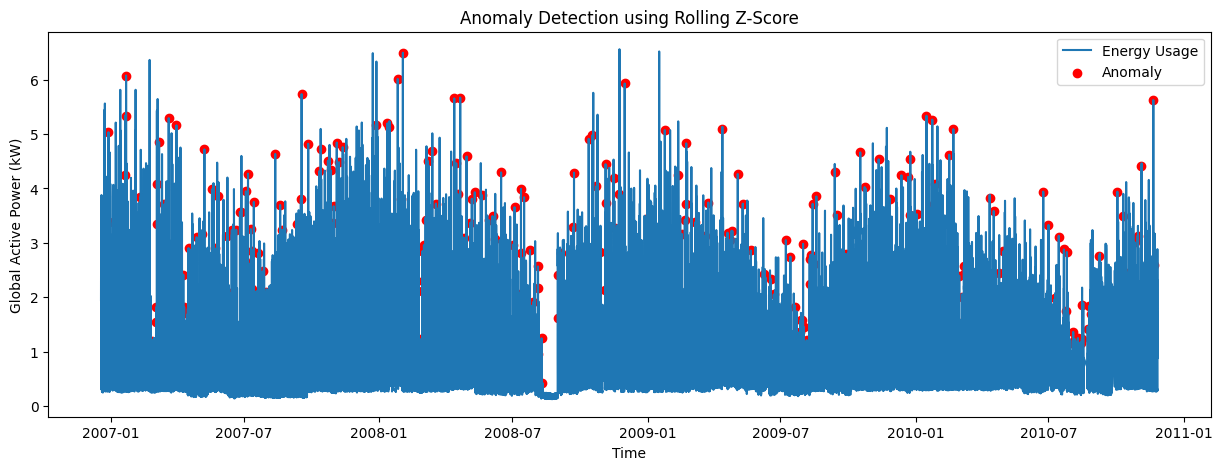

In [ ]:
# -------------------------------------------------------
# Plot Z-Score Anomalies
# -------------------------------------------------------

plt.figure(figsize=(15,5))

plt.plot(df_hourly.index, df_hourly['Global_active_power'], label='Energy Usage')

anomalies = df_hourly[df_hourly['z_anomaly'] == 1]

plt.scatter(anomalies.index,
            anomalies['Global_active_power'],
            color='red',
            label='Anomaly')

plt.title("Anomaly Detection using Rolling Z-Score")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.legend()

plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
# -------------------------------------------------------
# Features for Isolation Forest
# -------------------------------------------------------

iso_features = df_hourly[['Global_active_power',
                          'Voltage',
                          'Global_intensity',
                          'Sub_metering_1',
                          'Sub_metering_2',
                          'Sub_metering_3']]

iso_features.head()

,Global_active_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,
2006-12-18 16:00:00,1.949300,242.380667,8.096667,0.0,0.000000,17.983333
2006-12-18 17:00:00,2.154900,238.729167,8.993333,0.0,0.333333,17.450000
2006-12-18 18:00:00,2.402533,236.668500,10.083333,0.0,0.250000,16.916667
2006-12-18 19:00:00,2.614500,235.329167,11.190000,0.0,9.100000,0.000000
2006-12-18 20:00:00,3.050567,234.524333,13.046667,0.0,0.500000,13.250000


In [ ]:
# -------------------------------------------------------
# Train Isolation Forest
# -------------------------------------------------------

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

df_hourly['iso_anomaly'] = iso_model.fit_predict(iso_features)

df_hourly['iso_anomaly'] = df_hourly['iso_anomaly'].map({1:0, -1:1})

print("Isolation Forest anomalies:", df_hourly['iso_anomaly'].sum())

Isolation Forest anomalies: 342


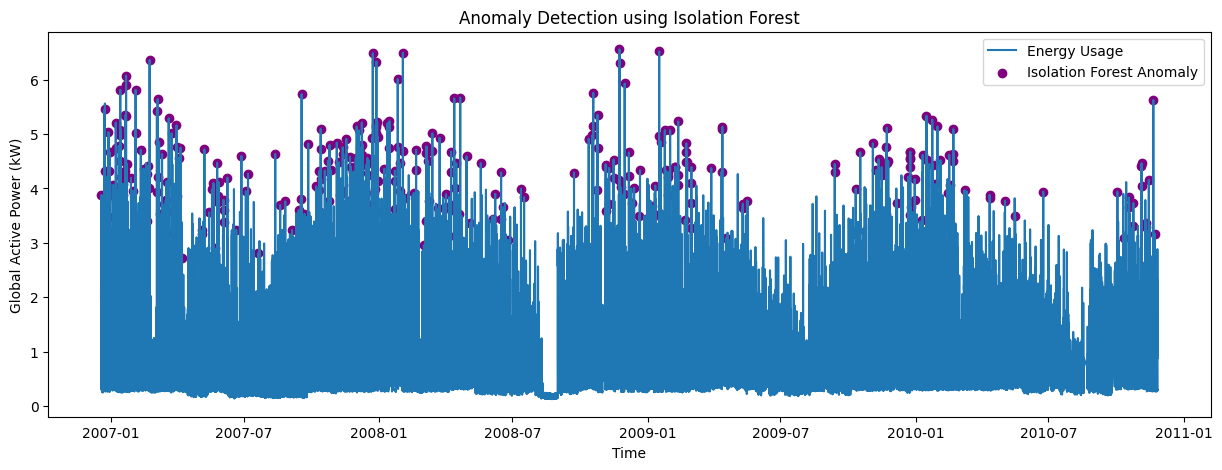

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df_hourly.index, df_hourly['Global_active_power'], label='Energy Usage')

iso_anomalies = df_hourly[df_hourly['iso_anomaly'] == 1]

plt.scatter(iso_anomalies.index,
            iso_anomalies['Global_active_power'],
            color='purple',
            label='Isolation Forest Anomaly')

plt.title("Anomaly Detection using Isolation Forest")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.legend()

plt.show()

In [ ]:
# -------------------------------------------------------
# Prophet Residual Calculation
# -------------------------------------------------------

prophet_results = forecast.set_index('ds')

df_hourly['prophet_pred'] = prophet_results.loc[df_hourly.index]['yhat']

df_hourly['residual'] = df_hourly['Global_active_power'] - df_hourly['prophet_pred']

df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,lag1,lag24,rolling_24,rolling_mean,rolling_std,z_score,z_anomaly,iso_anomaly,prophet_pred,residual
DateTime,,,,,,,,,,,,,,,,,,,
2006-12-18 16:00:00,1.949300,0.204433,242.380667,8.096667,0.0,0.000000,17.983333,16,0,1.784300,3.326033,1.642600,1.642600,1.082119,0.283425,0,0,1.391918,0.557382
2006-12-18 17:00:00,2.154900,0.097800,238.729167,8.993333,0.0,0.333333,17.450000,17,0,1.949300,3.406767,1.590439,1.590439,1.021879,0.552376,0,0,1.502327,0.652573
2006-12-18 18:00:00,2.402533,0.079100,236.668500,10.083333,0.0,0.250000,16.916667,18,0,2.154900,3.697100,1.536499,1.536499,0.936439,0.924817,0,0,1.848635,0.553898
2006-12-18 19:00:00,2.614500,0.200767,235.329167,11.190000,0.0,9.100000,0.000000,19,0,2.402533,2.908400,1.524253,1.524253,0.919487,1.185713,0,0,2.248607,0.365893
2006-12-18 20:00:00,3.050567,0.120367,234.524333,13.046667,0.0,0.500000,13.250000,20,0,2.614500,3.361500,1.511297,1.511297,0.894320,1.721161,0,0,2.439990,0.610577


In [ ]:
# -------------------------------------------------------
# Prophet Residual Z-Score
# -------------------------------------------------------

residual_mean = df_hourly['residual'].mean()
residual_std = df_hourly['residual'].std()

df_hourly['residual_zscore'] = (
    (df_hourly['residual'] - residual_mean) / residual_std
)

threshold = 3

df_hourly['prophet_anomaly'] = np.where(abs(df_hourly['residual_zscore']) > threshold, 1, 0)

print("Prophet anomalies:", df_hourly['prophet_anomaly'].sum())

Prophet anomalies: 413


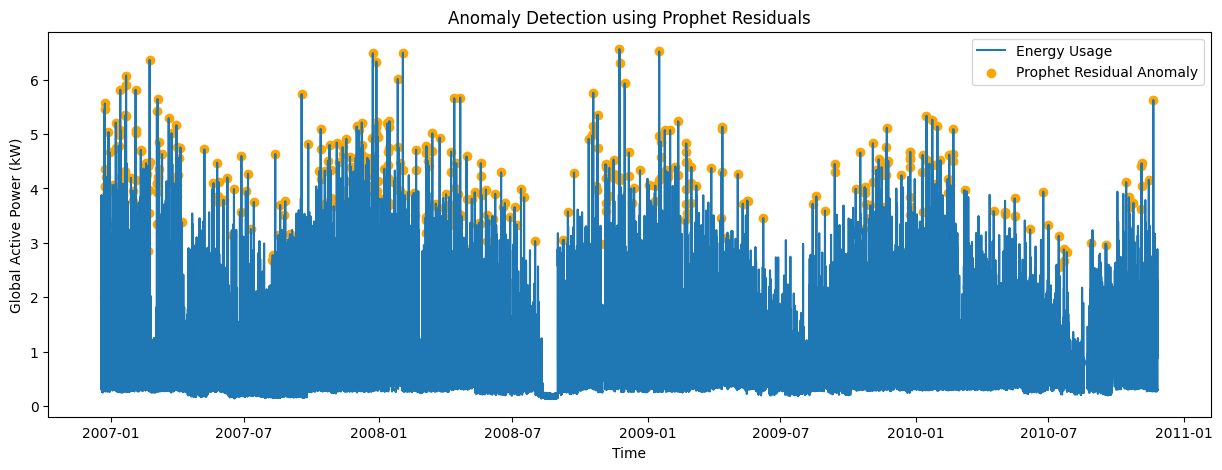

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df_hourly.index, df_hourly['Global_active_power'], label='Energy Usage')

prophet_anomalies = df_hourly[df_hourly['prophet_anomaly'] == 1]

plt.scatter(prophet_anomalies.index,
            prophet_anomalies['Global_active_power'],
            color='orange',
            label='Prophet Residual Anomaly')

plt.title("Anomaly Detection using Prophet Residuals")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.legend()

plt.show()

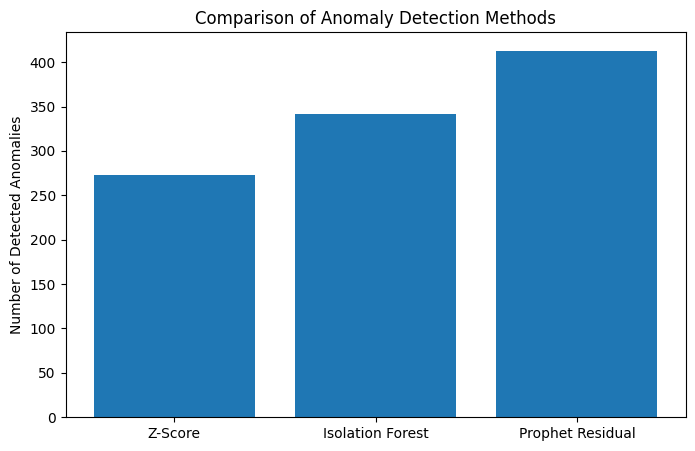

In [ ]:
# -------------------------------------------------------
# Anomaly Detection Comparison
# -------------------------------------------------------

methods = ['Z-Score','Isolation Forest','Prophet Residual']

counts = [273,342,413]

plt.figure(figsize=(8,5))

plt.bar(methods, counts)

plt.title("Comparison of Anomaly Detection Methods")
plt.ylabel("Number of Detected Anomalies")

plt.show()